## **Post Lab Task 1**: Classification on Titanic Dataset

In [1]:
import pandas as pd


In [2]:
import matplotlib.pyplot as plt


In [3]:
import seaborn as sns


In [4]:
from sklearn.model_selection import train_test_split


In [5]:
from sklearn.preprocessing import LabelEncoder


In [6]:
from sklearn.tree import DecisionTreeClassifier


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [8]:
titanic = sns.load_dataset('titanic')


In [9]:
data = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()


In [10]:
data['age'] = data['age'].fillna(data['age'].median())


In [11]:
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])


In [12]:
encoder = LabelEncoder()


In [13]:
data['sex'] = encoder.fit_transform(data['sex'])


In [14]:
data['embarked'] = encoder.fit_transform(data['embarked'])


In [15]:
X = data.drop('survived', axis=1)


In [16]:
y = data['survived']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [18]:
model = DecisionTreeClassifier(random_state=42)


In [19]:
model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred = model.predict(X_test)


In [21]:
accuracy = accuracy_score(y_test, y_pred)


In [22]:
print("Accuracy:", round(accuracy, 4))


Accuracy: 0.7654


In [23]:
cm = confusion_matrix(y_test, y_pred)


In [24]:
print("\nConfusion Matrix:")



Confusion Matrix:


In [25]:
print(cm)


[[82 23]
 [19 55]]


In [26]:
print("\nClassification Report:")



Classification Report:


In [27]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



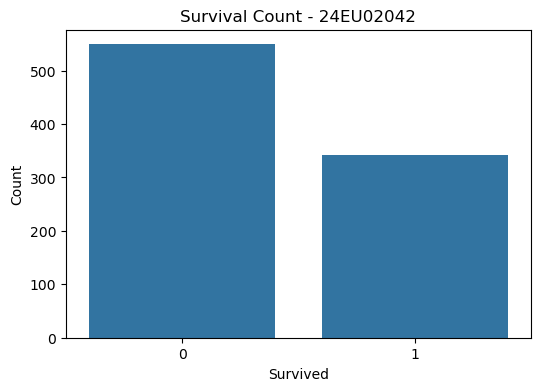

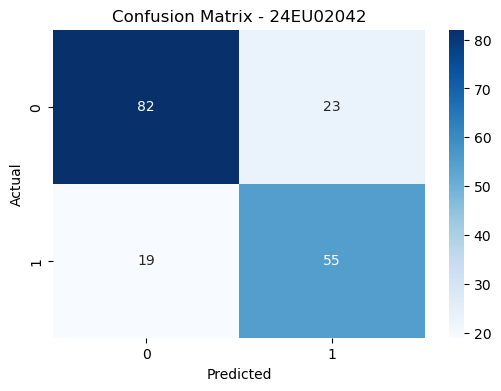

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=data)
plt.title("Survival Count - 24EU02042")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - 24EU02042")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## **Post Lab Task 2**: Regression on California Housing Dataset

In [29]:
import warnings


In [30]:
warnings.filterwarnings("ignore")


In [31]:
import matplotlib.pyplot as plt


In [32]:
import numpy as np


In [33]:
from sklearn.datasets import fetch_california_housing


In [34]:
from sklearn.model_selection import train_test_split


In [35]:
from sklearn.linear_model import LinearRegression


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [37]:
housing = fetch_california_housing()


In [38]:
X = housing.data


In [39]:
y = housing.target


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [41]:
model = LinearRegression()


In [42]:
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred = model.predict(X_test)


In [44]:
mae = mean_absolute_error(y_test, y_pred)


In [45]:
mse = mean_squared_error(y_test, y_pred)


In [46]:
rmse = np.sqrt(mse)


In [47]:
r2 = r2_score(y_test, y_pred)


In [48]:
print("Mean Absolute Error:", round(mae, 3))


Mean Absolute Error: 0.533


In [49]:
print("Mean Squared Error:", round(mse, 3))


Mean Squared Error: 0.556


In [50]:
print("Root Mean Squared Error:", round(rmse, 3))


Root Mean Squared Error: 0.746


In [51]:
print("R2 Score:", round(r2, 3))


R2 Score: 0.576


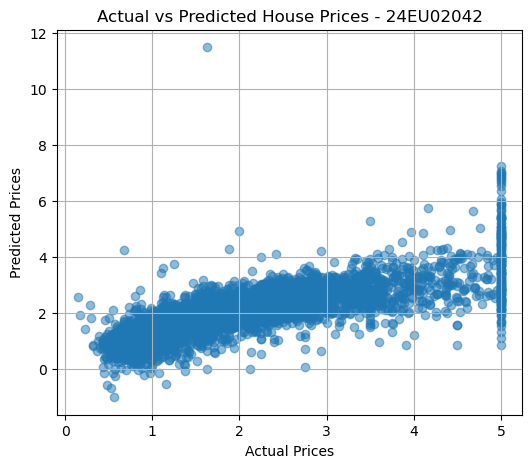

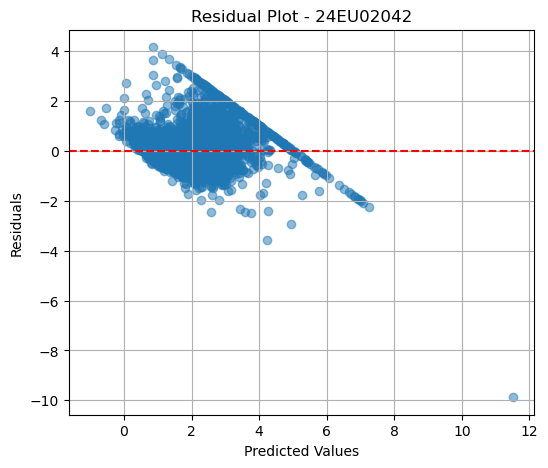

In [52]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices - 24EU02042")
plt.grid(True)
plt.show()
plt.figure(figsize=(6,5))
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - 24EU02042")
plt.grid(True)
plt.show()
